In [1]:
import sys
sys.path.append("..")  # pour trouver les modules du projet

import pandas as pd
import matplotlib.pyplot as plt
from data.loader import download_data, compute_returns
from backtester.engine import Backtester

plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
data = download_data("AAPL", "2018-01-01", "2024-01-01")
data = compute_returns(data)
data.tail()  # affiche les 5 dernières lignes dans Jupyter

Price,Open,High,Low,Close,Volume,returns
Date,,,,,,
2023-12-22,193.173193,193.400839,190.985924,191.609451,37149600,-0.005548
2023-12-26,191.619380,191.896500,190.847401,191.065140,28919300,-0.002841
2023-12-27,190.510906,191.510516,189.125291,191.164108,48087700,0.000518
2023-12-28,192.143900,192.658558,191.183873,191.589661,34049900,0.002226
2023-12-29,191.906385,192.401245,189.758698,190.550476,42672100,-0.005424


In [3]:
bt = Backtester(data, initial_capital=10000)
output = bt.run(window=20)

# Affiche les métriques
for k, v in output["metrics"].items():
    print(f"{k:20} : {v}")

CAGR                 : 33.55
Sharpe               : 1.52
Max Drawdown         : -22.47
Capital final        : 56486.27
Nb jours tradés      : 951


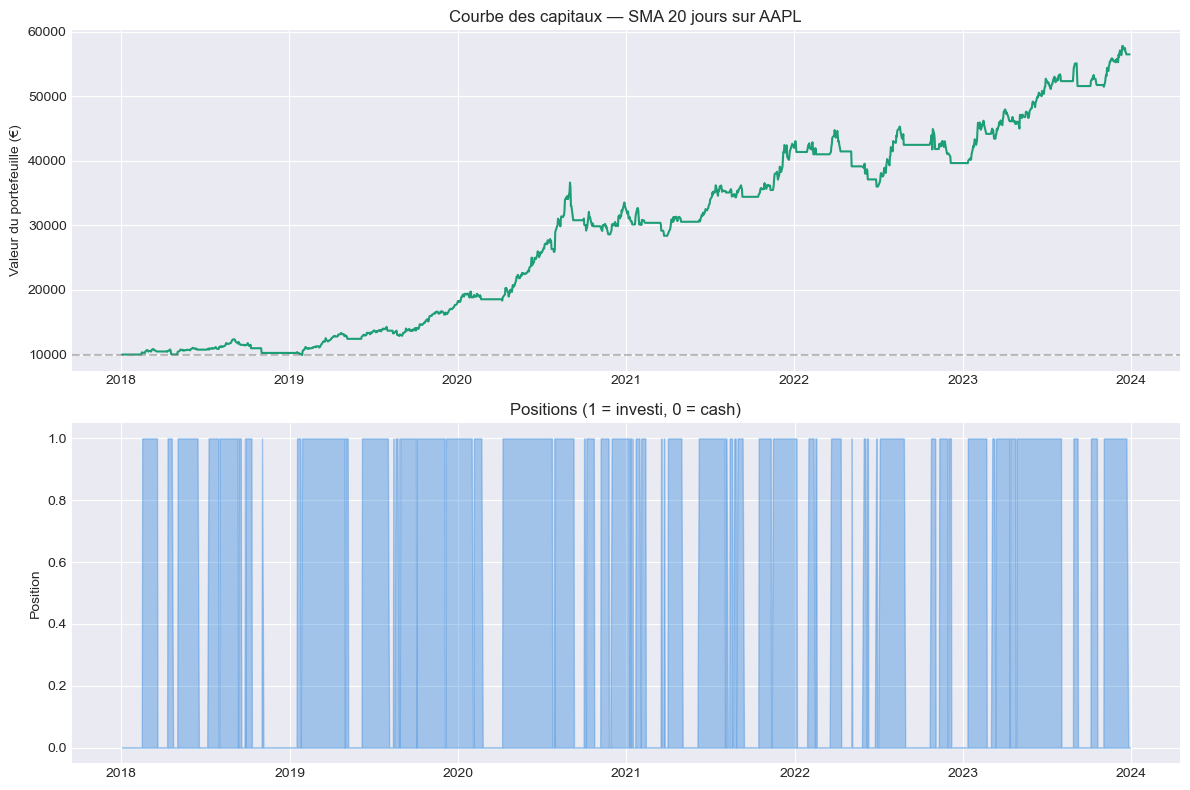

In [6]:
results = output["results"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Graphique 1 : courbe des capitaux
axes[0].plot(results.index, results["equity_curve"], color="#1D9E75", linewidth=1.5)
axes[0].axhline(y=10000, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("Courbe des capitaux — SMA 20 jours sur AAPL")
axes[0].set_ylabel("Valeur du portefeuille (€)")

# Graphique 2 : positions (quand on est investi)
axes[1].fill_between(results.index, results["position"],
                     alpha=0.4, color="#378ADD")
axes[1].set_title("Positions (1 = investi, 0 = cash)")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.show()